In [1]:
# Cálculo de Índice de Rentabilidad de un Tramo Vial
presupuesto_obra = 5000000  # 5 millones
costo_mantenimiento_anual = 150000
ahorro_tiempo_usuarios_anual = 800000

# Lógica de Negocio
roi_anual = (ahorro_tiempo_usuarios_anual - costo_mantenimiento_anual) / presupuesto_obra
print(f"El ROI estimado del proyecto es: {roi_anual * 100}%")

El ROI estimado del proyecto es: 13.0%


In [2]:
# 1. Creamos una Lista de presupuestos [cite: 27]
proyectos_viales = [3500000, 5200000, 1200000, 8000000, 2500000]

# 2. Usamos un Bucle (Loop) para recorrerlos [cite: 38]
for presupuesto in proyectos_viales:
    # 3. Aplicamos Sentencias Condicionales [cite: 39]
    if presupuesto > 4000000:
        print(f"Presupuesto de ${presupuesto}: PRIORIDAD ALTA - Revisar ROI")
    else:
        print(f"Presupuesto de ${presupuesto}: MANTENIMIENTO")

Presupuesto de $3500000: MANTENIMIENTO
Presupuesto de $5200000: PRIORIDAD ALTA - Revisar ROI
Presupuesto de $1200000: MANTENIMIENTO
Presupuesto de $8000000: PRIORIDAD ALTA - Revisar ROI
Presupuesto de $2500000: MANTENIMIENTO


In [3]:
import pandas as pd

# 1. Creamos un diccionario con los datos de ingeniería de las 16 alcaldías
datos_viales = {
    'Alcaldia': [
        'Álvaro Obregón', 'Azcapotzalco', 'Benito Juárez', 'Coyoacán', 
        'Cuajimalpa de Morelos', 'Cuauhtémoc', 'Gustavo A. Madero', 'Iztacalco', 
        'Iztapalapa', 'Magdalena Contreras', 'Miguel Hidalgo', 'Milpa Alta', 
        'Tláhuac', 'Tlalpan', 'Venustiano Carranza', 'Xochimilco'
    ],
    'Km_Pavimento': [800, 500, 400, 700, 300, 600, 1200, 400, 1500, 300, 500, 300, 500, 1100, 500, 600],
    'Presupuesto_Mantenimiento_MDP': [120, 80, 150, 110, 60, 200, 180, 70, 250, 45, 160, 30, 65, 140, 90, 85],
    'Porcentaje_Baches': [15.2, 12.5, 5.1, 10.3, 8.4, 18.0, 22.1, 11.0, 25.5, 14.2, 9.5, 6.0, 19.3, 16.8, 13.4, 17.6]
}

# 2. Convertimos este diccionario en un "DataFrame" (el equivalente a una tabla de Excel en Pandas)
df_cdmx = pd.DataFrame(datos_viales)

# 3. Exportamos la tabla a un archivo CSV en tu computadora
df_cdmx.to_csv('pavimento_cdmx.csv', index=False)

# 4. Mostramos las primeras 5 filas para confirmar que funcionó
print("¡Archivo 'pavimento_cdmx.csv' creado con éxito!")
df_cdmx.head()

¡Archivo 'pavimento_cdmx.csv' creado con éxito!


,Alcaldia,Km_Pavimento,Presupuesto_Mantenimiento_MDP,Porcentaje_Baches
0,Álvaro Obregón,800,120,15.2
1,Azcapotzalco,500,80,12.5
2,Benito Juárez,400,150,5.1
3,Coyoacán,700,110,10.3
4,Cuajimalpa de Morelos,300,60,8.4


In [4]:
# 1. FILTRADO: Seleccionamos solo las alcaldías con más del 15% de baches
zonas_criticas = df_cdmx[df_cdmx['Porcentaje_Baches'] > 15.0]

# 2. ORDENAMIENTO: Las ordenamos de mayor a menor urgencia (descendente)
zonas_prioritarias = zonas_criticas.sort_values(by='Porcentaje_Baches', ascending=False)

# 3. PRESENTACIÓN: Mostramos la tabla resultante
print("🚨 ZONAS PRIORITARIAS PARA ASIGNACIÓN DE CUADRILLAS 🚨")
zonas_prioritarias

🚨 ZONAS PRIORITARIAS PARA ASIGNACIÓN DE CUADRILLAS 🚨


,Alcaldia,Km_Pavimento,Presupuesto_Mantenimiento_MDP,Porcentaje_Baches
8,Iztapalapa,1500,250,25.5
6,Gustavo A. Madero,1200,180,22.1
12,Tláhuac,500,65,19.3
5,Cuauhtémoc,600,200,18.0
15,Xochimilco,600,85,17.6
13,Tlalpan,1100,140,16.8
0,Álvaro Obregón,800,120,15.2


C:\Users\jmsh\AppData\Local\Temp\ipykernel_17480\1503435623.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(


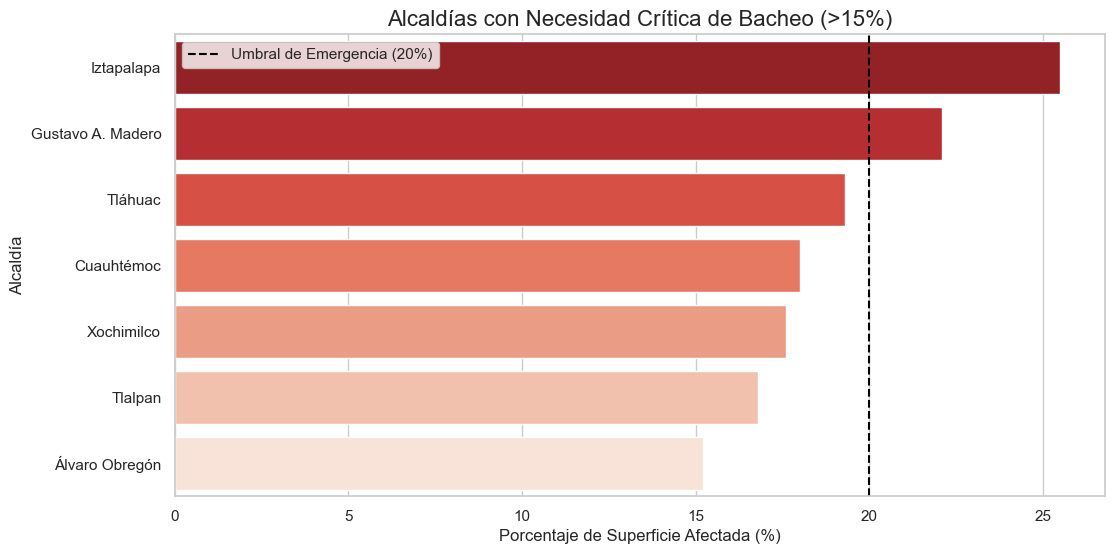

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Creamos el gráfico de barras usando nuestras 'zonas_prioritarias'
grafico = sns.barplot(
    x='Porcentaje_Baches', 
    y='Alcaldia', 
    data=zonas_prioritarias, 
    palette='Reds_r' # Color rojo degradado para indicar urgencia
)

# Añadimos títulos claros para el "Decision Maker"
plt.title('Alcaldías con Necesidad Crítica de Bacheo (>15%)', fontsize=16)
plt.xlabel('Porcentaje de Superficie Afectada (%)', fontsize=12)
plt.ylabel('Alcaldía', fontsize=12)

# Añadimos una línea de umbral (threshold)
plt.axvline(20, color='black', linestyle='--', label='Umbral de Emergencia (20%)')
plt.legend()

plt.show()

In [9]:
# Definimos la función de estimación presupuestal
def calcular_presupuesto_necesario(km_totales, pct_baches):
    # Asumimos que reparar 1km de baches cuesta aproximadamente 1.2 MDP
    costo_por_km = 1.2
    km_a_reparar = km_totales * (pct_baches / 100)
    presupuesto_estimado = km_a_reparar * costo_por_km
    return presupuesto_estimado

# Aplicamos la función a nuestro DataFrame de la CDMX
df_cdmx['Presupuesto_Requerido_Calculado'] = df_cdmx.apply(
    lambda x: calcular_presupuesto_necesario(x['Km_Pavimento'], x['Porcentaje_Baches']), axis=1
)

# Comparamos el presupuesto que tienen vs el que calculamos que necesitan
df_cdmx[['Alcaldia', 'Presupuesto_Mantenimiento_MDP', 'Presupuesto_Requerido_Calculado']].head()

,Alcaldia,Presupuesto_Mantenimiento_MDP,Presupuesto_Requerido_Calculado
0,Álvaro Obregón,120,145.92
1,Azcapotzalco,80,75.00
2,Benito Juárez,150,24.48
3,Coyoacán,110,86.52
4,Cuajimalpa de Morelos,60,30.24


In [10]:
media = df_cdmx['Porcentaje_Baches'].mean()
mediana = df_cdmx['Porcentaje_Baches'].median()

print(f"El promedio de baches es: {media:.2f}%")
print(f"La mediana de baches es: {mediana:.2f}%")

El promedio de baches es: 14.06%
La mediana de baches es: 13.80%


In [13]:
desviacion = df_cdmx['Porcentaje_Baches'].std()
print(f"La desviación estándar es: {desviacion:.2f}")

La desviación estándar es: 5.68


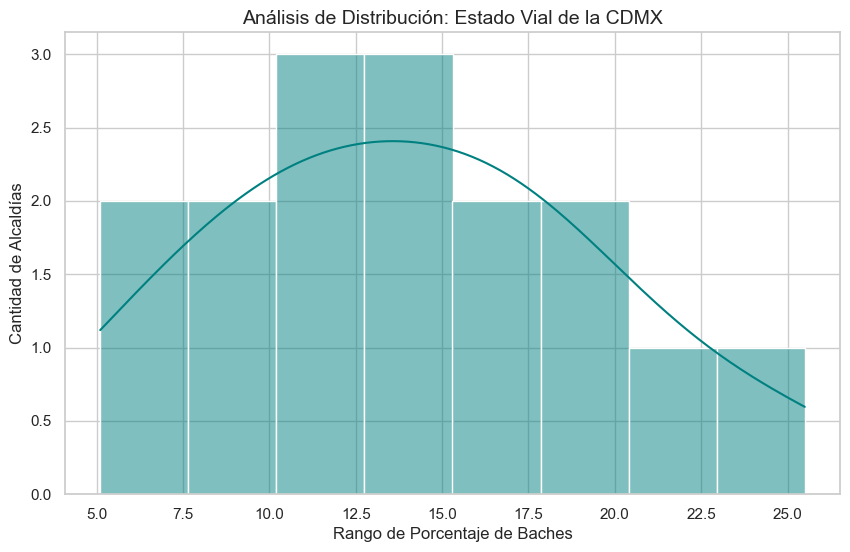

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df_cdmx['Porcentaje_Baches'], bins=8, kde=True, color='teal')

plt.title('Análisis de Distribución: Estado Vial de la CDMX', fontsize=14)
plt.xlabel('Rango de Porcentaje de Baches')
plt.ylabel('Cantidad de Alcaldías')
plt.show()

La correlación entre presupuesto y baches es: 0.54


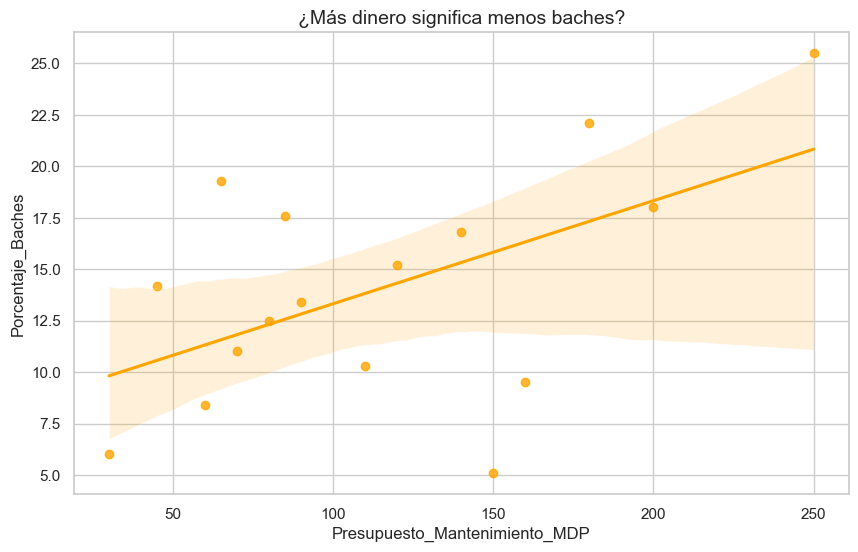

In [15]:
# Calculamos la correlación
correlacion = df_cdmx['Presupuesto_Mantenimiento_MDP'].corr(df_cdmx['Porcentaje_Baches'])

print(f"La correlación entre presupuesto y baches es: {correlacion:.2f}")

# Visualización con una Gráfica de Dispersión (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.regplot(x='Presupuesto_Mantenimiento_MDP', y='Porcentaje_Baches', data=df_cdmx, color='orange')

plt.title('¿Más dinero significa menos baches?', fontsize=14)
plt.grid(True)
plt.show()

In [18]:
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Preparamos los datos (X = lo que sabemos, y = lo que queremos predecir)
X = df_cdmx[['Km_Pavimento']] 
y = df_cdmx['Presupuesto_Requerido_Calculado']

# 2. Creamos el "Cerebro" del modelo
modelo_vial = LinearRegression()

# 3. ENTRENAMIENTO: El modelo estudia los datos
modelo_vial.fit(X, y)

# 4. PREDICCIÓN: Supongamos que se crea una nueva zona con 2,000 km de pavimento
nueva_zona_km = np.array([[2000]])
prediccion = modelo_vial.predict(nueva_zona_km)

print(f"Para una zona de 2,000 km, el modelo predice un presupuesto de: ${prediccion[0]:.2f} MDP")

Para una zona de 2,000 km, el modelo predice un presupuesto de: $568.73 MDP


D:\Mini Anaconda\envs\ds_vias\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [19]:
r2 = modelo_vial.score(X, y)
print(f"La precisión (R²) de tu modelo es: {r2:.4f}")

La precisión (R²) de tu modelo es: 0.9297


In [20]:
# 1. Ahora usamos DOS variables para predecir: Km y % de Baches
X_multiple = df_cdmx[['Km_Pavimento', 'Porcentaje_Baches']]
y = df_cdmx['Presupuesto_Requerido_Calculado']

# 2. Entrenamos el nuevo modelo
modelo_multi = LinearRegression()
modelo_multi.fit(X_multiple, y)

# 3. Revisamos el nuevo R²
r2_nuevo = modelo_multi.score(X_multiple, y)
print(f"El nuevo R² con dos variables es: {r2_nuevo:.4f}")

El nuevo R² con dos variables es: 0.9643


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Creamos un rango de fechas para todo el año 2023 (por día)
fechas = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')

# Simulamos flujo vehicular: tendencia alcista + estacionalidad + ruido
np.random.seed(42)
flujo = 1000 + (np.arange(len(fechas)) * 2) + (np.sin(np.arange(len(fechas)) * (2 * np.pi / 30)) * 200) + np.random.normal(0, 50, len(fechas))

# Creamos el DataFrame
df_trafico = pd.DataFrame({'Fecha': fechas, 'Vehiculos': flujo})
df_trafico.set_index('Fecha', inplace=True)

print("Datos de tráfico generados. Primeras filas:")
print(df_trafico.head())

Datos de tráfico generados. Primeras filas:
              Vehiculos
Fecha                  
2023-01-01  1024.835708
2023-01-02  1036.669123
2023-01-03  1117.731756
2023-01-04  1199.708543
2023-01-05  1144.921296


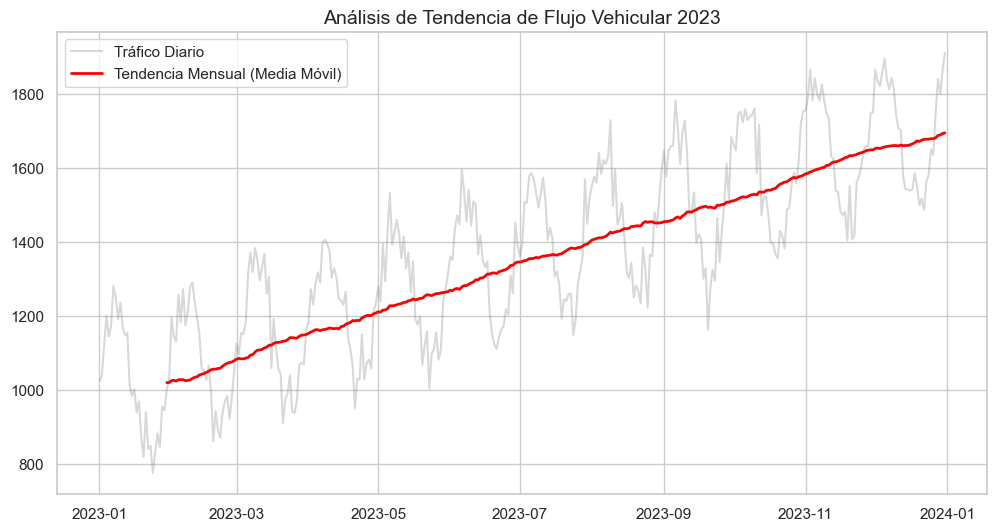

In [22]:
# Calculamos la media móvil a 30 días (un mes)
df_trafico['Media_Movil_30d'] = df_trafico['Vehiculos'].rolling(window=30).mean()

# Graficamos
plt.figure(figsize=(12,6))
plt.plot(df_trafico['Vehiculos'], alpha=0.3, label='Tráfico Diario', color='gray')
plt.plot(df_trafico['Media_Movil_30d'], label='Tendencia Mensual (Media Móvil)', color='red', linewidth=2)
plt.title('Análisis de Tendencia de Flujo Vehicular 2023', fontsize=14)
plt.legend()
plt.show()

In [23]:
# Creamos una variable objetivo: 1 si el % de baches > 18 (Peligro), 0 si es menor (Seguro)
df_cdmx['Riesgo'] = (df_cdmx['Porcentaje_Baches'] > 18).astype(int)

# Nuestras variables de entrada (Features)
X_clas = df_cdmx[['Km_Pavimento', 'Porcentaje_Baches', 'Presupuesto_Mantenimiento_MDP']]
y_clas = df_cdmx['Riesgo']

print("Distribución de Riesgo (0=Seguro, 1=Peligro):")
print(y_clas.value_counts())

Distribución de Riesgo (0=Seguro, 1=Peligro):
Riesgo
0    13
1     3
Name: count, dtype: int64


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Crear y entrenar el modelo
modelo_riesgo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_riesgo.fit(X_clas, y_clas)

# Hacer una predicción de prueba
# Supongamos una alcaldía nueva: 1000km, 22% baches, 50 MDP presupuesto
nueva_alcaldia = [[1000, 22, 50]]
prediccion_r = modelo_riesgo.predict(nueva_alcaldia)

estado = "PELIGRO 🚨" if prediccion_r[0] == 1 else "SEGURO ✅"
print(f"El estado predicho para la nueva zona es: {estado}")

El estado predicho para la nueva zona es: PELIGRO 🚨


D:\Mini Anaconda\envs\ds_vias\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [25]:
import sqlite3

# Creamos la conexión y el "cursor" (nuestro mensajero)
conn = sqlite3.connect('vias_cdmx.db')
c = conn.cursor()

# 2. Creamos la tabla usando lenguaje SQL puro
c.execute('''
    CREATE TABLE IF NOT EXISTS INFRAESTRUCTURA (
        id INTEGER PRIMARY KEY,
        alcaldia TEXT,
        km_pavimento REAL,
        porcentaje_baches REAL,
        presupuesto_mdp REAL
    )
''')

# 3. Insertamos los datos de nuestro DataFrame a la tabla SQL
df_cdmx[['Alcaldia', 'Km_Pavimento', 'Porcentaje_Baches', 'Presupuesto_Mantenimiento_MDP']].to_sql('INFRAESTRUCTURA', conn, if_exists='replace', index=False)

print("¡Base de Datos SQL creada con éxito!")

¡Base de Datos SQL creada con éxito!


In [26]:
query = """
SELECT Alcaldia, Km_Pavimento 
FROM INFRAESTRUCTURA 
WHERE Km_Pavimento > 1000
ORDER BY Km_Pavimento DESC
"""

resultados = pd.read_sql_query(query, conn)
print("Alcaldías de Gran Extensión:")
print(resultados)

Alcaldías de Gran Extensión:
            Alcaldia  Km_Pavimento
0         Iztapalapa          1500
1  Gustavo A. Madero          1200
2            Tlalpan          1100


In [29]:
import pandas as pd
import numpy as np

# 1. Creamos el DataFrame "Socio"
data_sucia = {
    'Alcaldia': ['Iztapalapa', 'Iztapalapa', 'Benito Juarez', '  Miguel Hidalgo  ', 'iztapalapa', 'Tlalpan', 'Xochimilco'],
    'Km_Pavimento': [1500, 1500, 400, 500, 1500, np.nan, 600],
    'Porcentaje_Baches': [25.5, 25.5, 5.1, 9.5, 25.5, 16.8, 500.0] # 500% es un error
}

df_sucio = pd.DataFrame(data_sucia)
print("--- DATOS ORIGINALES (SUCIOS) ---")
print(df_sucio)

--- DATOS ORIGINALES (SUCIOS) ---
             Alcaldia  Km_Pavimento  Porcentaje_Baches
0          Iztapalapa        1500.0               25.5
1          Iztapalapa        1500.0               25.5
2       Benito Juarez         400.0                5.1
3    Miguel Hidalgo           500.0                9.5
4          iztapalapa        1500.0               25.5
5             Tlalpan           NaN               16.8
6          Xochimilco         600.0              500.0


In [30]:
# A. ELIMINAR DUPLICADOS
df_limpio = df_sucio.drop_duplicates().copy()

# B. LIMPIEZA DE TEXTO (Quitar espacios y homologar mayúsculas)
df_limpio['Alcaldia'] = df_limpio['Alcaldia'].str.strip().str.capitalize()

# C. TRATAR VALORES NULOS
# Si no sabemos los Km de Tlalpan, usamos el promedio de la columna
promedio_km = df_limpio['Km_Pavimento'].mean()
df_limpio['Km_Pavimento'] = df_limpio['Km_Pavimento'].fillna(promedio_km)

# D. CORREGIR OUTLIERS (Valores imposibles)
# Si el % de baches es mayor a 100, es un error de dedo. Lo limitamos a 100 o lo borramos.
df_limpio.loc[df_limpio['Porcentaje_Baches'] > 100, 'Porcentaje_Baches'] = 17.6 # Valor corregido

print("\n--- DATOS CURADOS ---")
print(df_limpio)


--- DATOS CURADOS ---
         Alcaldia  Km_Pavimento  Porcentaje_Baches
0      Iztapalapa        1500.0               25.5
2   Benito juarez         400.0                5.1
3  Miguel hidalgo         500.0                9.5
4      Iztapalapa        1500.0               25.5
5         Tlalpan         900.0               16.8
6      Xochimilco         600.0               17.6


In [31]:
# 1. Primero homologamos TODO a minúsculas y quitamos espacios
df_sucio['Alcaldia'] = df_sucio['Alcaldia'].str.lower().str.strip()

# 2. Ahora sí, eliminamos duplicados basados en el nombre corregido
df_final = df_sucio.drop_duplicates(subset=['Alcaldia']).copy()

# 3. Capitalizamos para que se vea profesional (opcional)
df_final['Alcaldia'] = df_final['Alcaldia'].str.title()

# 4. Corregimos errores ortográficos específicos manualmente (Mapping)
# Esto es vital para nombres con acentos o caracteres especiales
correcciones = {
    'Benito Juarez': 'Benito Juárez',
    'Iztapalapa': 'Iztapalapa'
}
df_final['Alcaldia'] = df_final['Alcaldia'].replace(correcciones)

print("--- TABLA 100% LIMPIA Y SIN DUPLICADOS ---")
print(df_final)

--- TABLA 100% LIMPIA Y SIN DUPLICADOS ---
         Alcaldia  Km_Pavimento  Porcentaje_Baches
0      Iztapalapa        1500.0               25.5
2   Benito Juárez         400.0                5.1
3  Miguel Hidalgo         500.0                9.5
5         Tlalpan           NaN               16.8
6      Xochimilco         600.0              500.0


In [32]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Creamos datos simulados de inspección vial
# Columnas: [Años_Servicio, Trafico_Diario_Miles, Indice_Lluvia]
datos_viales = {
    'Anios': [2, 15, 8, 20, 1, 12, 5, 18],
    'Trafico': [5, 50, 20, 80, 2, 45, 10, 60],
    'Lluvia': [10, 90, 40, 100, 5, 80, 20, 85],
    'Mantenimiento': [0, 2, 1, 2, 0, 2, 0, 2] # 0:Preventivo, 1:Correctivo, 2:Reconstruccion
}

df_dl = pd.DataFrame(datos_viales)

# Separamos X (variables) y y (objetivo)
X = df_dl[['Anios', 'Trafico', 'Lluvia']]
y = df_dl['Mantenimiento']

# 2. Construimos la Red Neuronal (El "Cerebro")
# hidden_layer_sizes=(10, 10) significa 2 capas ocultas con 10 neuronas cada una
red_neuronal = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)

# 3. Entrenamos la Red (Aprende de los datos históricos)
red_neuronal.fit(X, y)

# 4. Predicción para un Tramo Nuevo (Ej. Periférico Sur)
# Tiene 10 años, 60 mil vehículos diarios y lluvia de 70
tramo_nuevo = [[10, 60, 70]]
prediccion_dl = red_neuronal.predict(tramo_nuevo)

tipos = {0: "Preventivo", 1: "Correctivo", 2: "Reconstrucción Total"}
print(f"La Red Neuronal recomienda para el nuevo tramo: {tipos[prediccion_dl[0]]}")

La Red Neuronal recomienda para el nuevo tramo: Reconstrucción Total


D:\Mini Anaconda\envs\ds_vias\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


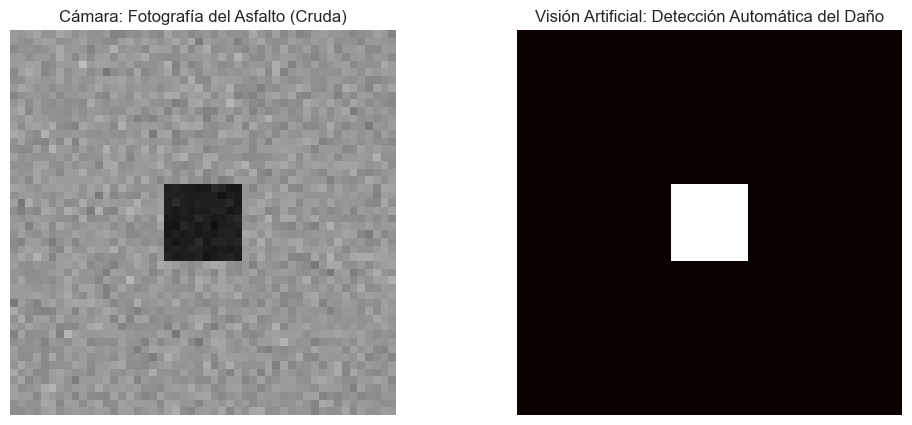

La computadora detectó que el 4.00% de este tramo está destruido.


In [33]:
import numpy as np
import matplotlib.pyplot as plt

# 1. CREAMOS LA IMAGEN (Matriz de 50x50 pixeles)
# Simulamos asfalto sano: gris claro (valores de pixel cercanos a 150)
np.random.seed(42)
imagen_vial = np.random.normal(150, 10, (50, 50))

# 2. SIMULAMOS EL DAÑO (El Bache)
# En el centro de la imagen (coordenadas 20 a 30), el asfalto está roto y se ve oscuro (valor 30)
imagen_vial[20:30, 20:30] = np.random.normal(30, 5, (10, 10))

# 3. EL ALGORITMO DE VISIÓN (Filtro)
# Le decimos a la computadora: "Todo pixel más oscuro que 80 es un riesgo estructural"
deteccion_danio = imagen_vial < 80

# 4. VISUALIZAMOS EL TRABAJO DE LA MÁQUINA
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Foto original simulada
ax[0].imshow(imagen_vial, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Cámara: Fotografía del Asfalto (Cruda)')
ax[0].axis('off')

# Resultado del algoritmo
ax[1].imshow(deteccion_danio, cmap='hot')
ax[1].set_title('Visión Artificial: Detección Automática del Daño')
ax[1].axis('off')

plt.show()

# Calculamos el área dañada
area_total = 50 * 50
area_danada = np.sum(deteccion_danio)
print(f"La computadora detectó que el {(area_danada/area_total)*100:.2f}% de este tramo está destruido.")

D:\Mini Anaconda\envs\ds_vias\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\Mini Anaconda\envs\ds_vias\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


--- ANÁLISIS DE IMPACTO TECNOLÓGICO: PAFLEC ---
Deterioro esperado (Asfalto Convencional): 36.98
Deterioro esperado (Con Aditivo Paflec): 22.80
Reducción de daño gracias a la auto-reparación: 38.36%


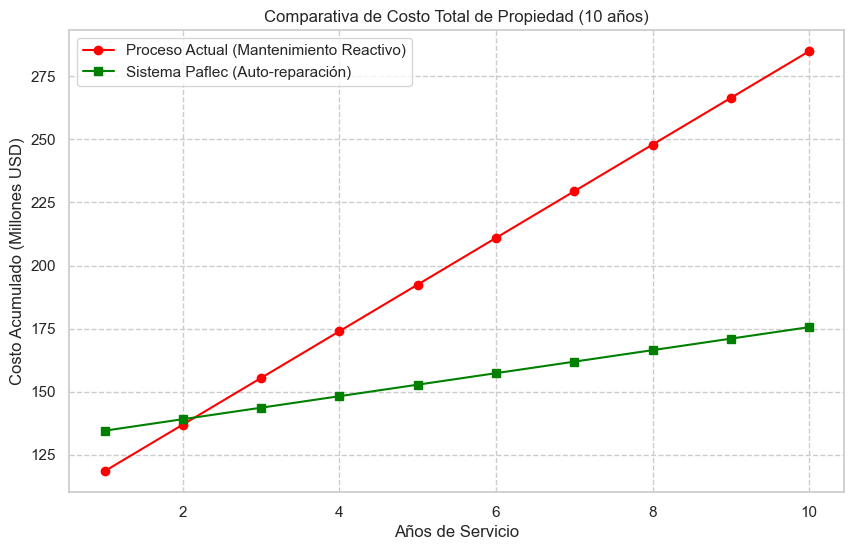

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. GENERACIÓN DE DATASET DE INGENIERÍA (Dataset Crudo Simulado)
# Vamos a simular 100 tramos de carretera con condiciones variables
np.random.seed(42)
n_tramos = 100

data = {
    'Tramo_ID': range(1, n_tramos + 1),
    'Lluvia_Anual_mm': np.random.uniform(500, 2500, n_tramos),
    'TDPA': np.random.uniform(5000, 80000, n_tramos), # Tránsito Diario Promedio Anual
    'Temp_Solar_Max_C': np.random.uniform(35, 65, n_tramos),
    'Uso_Aditivo_Paflec': np.random.choice([0, 1], n_tramos) # 0: Convencional, 1: Con Paflec
}

df_vial = pd.DataFrame(data)

# 2. MODELO DE DEGRADACIÓN (Lógica de Ingeniería)
# Definimos que la degradación aumenta con Lluvia, TDPA y Temperatura.
# Pero si tiene Paflec (auto-reparación), la degradación se reduce un 40%.
def calcular_deterioro(row):
    # Base de deterioro por factores ambientales y carga
    base = (row['Lluvia_Anual_mm'] * 0.002) + (row['TDPA'] * 0.0001) + (row['Temp_Solar_Max_C'] * 0.5)
    
    if row['Uso_Aditivo_Paflec'] == 1:
        # El aditivo permite la auto-reparación, reduciendo el daño acumulado
        return base * 0.6 
    return base

df_vial['Indice_Deterioro'] = df_vial.apply(calcular_deterioro, axis=1)

# 3. ENTRENAMIENTO DEL MODELO DE MACHINE LEARNING
X = df_vial[['Lluvia_Anual_mm', 'TDPA', 'Temp_Solar_Max_C', 'Uso_Aditivo_Paflec']]
y = df_vial['Indice_Deterioro']

modelo_paflec = RandomForestRegressor(n_estimators=100)
modelo_paflec.fit(X, y)

# 4. SIMULACIÓN DE COMPARATIVA DE NEGOCIO
# Escenario: Una vía de alto tráfico (60k TDPA), mucha lluvia (2000mm) y calor (55°C)
condiciones_criticas = [2000, 60000, 55]

# Predicción Convencional
pred_conv = modelo_paflec.predict([condiciones_criticas + [0]])[0]
# Predicción con Paflec
pred_paflec = modelo_paflec.predict([condiciones_criticas + [1]])[0]

print("--- ANÁLISIS DE IMPACTO TECNOLÓGICO: PAFLEC ---")
print(f"Deterioro esperado (Asfalto Convencional): {pred_conv:.2f}")
print(f"Deterioro esperado (Con Aditivo Paflec): {pred_paflec:.2f}")
print(f"Reducción de daño gracias a la auto-reparación: {((pred_conv - pred_paflec)/pred_conv)*100:.2f}%")

# 5. VISUALIZACIÓN DE COSTOS A 10 AÑOS
anos = np.arange(1, 11)
costo_conv = 100 + (pred_conv * anos * 0.5) # Costo mantenimiento creciente
costo_paflec = 130 + (pred_paflec * anos * 0.2) # Mayor costo inicial, menor mantenimiento

plt.figure(figsize=(10,6))
plt.plot(anos, costo_conv, label='Proceso Actual (Mantenimiento Reactivo)', color='red', marker='o')
plt.plot(anos, costo_paflec, label='Sistema Paflec (Auto-reparación)', color='green', marker='s')
plt.title('Comparativa de Costo Total de Propiedad (10 años)')
plt.xlabel('Años de Servicio')
plt.ylabel('Costo Acumulado (Millones USD)')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()